# Zomato Bangalore Restaurant Data Analysis

### Exploratory Data Analysis using Python

This project analyzes restaurant data from Bangalore to identify patterns in
restaurant types, ratings, locations, cuisines, online ordering, table booking,
and approximate cost.

### Project Objective

The objective of this project is to analyze Bangalore restaurant data and
identify patterns in restaurant distribution, ratings, cuisines, online
ordering, table booking, and pricing using Python-based exploratory data
analysis.

## 1. Import Libraries

In [354]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [355]:
columns_to_use = [
    "name",
    "online_order",
    "book_table",
    "rate",
    "votes",
    "location",
    "rest_type",
    "dish_liked",
    "cuisines",
    "approx_cost(for two people)",
    "listed_in(type)",
    "listed_in(city)"
]
df = pd.read_csv(
    "../data/zomato.csv",
    usecols=columns_to_use
)

## 3. Understanding the Dataset

In [356]:
df.shape

(51717, 12)

In [357]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         51717 non-null  str  
 1   online_order                 51717 non-null  str  
 2   book_table                   51717 non-null  str  
 3   rate                         43942 non-null  str  
 4   votes                        51717 non-null  int64
 5   location                     51696 non-null  str  
 6   rest_type                    51490 non-null  str  
 7   dish_liked                   23639 non-null  str  
 8   cuisines                     51672 non-null  str  
 9   approx_cost(for two people)  51371 non-null  str  
 10  listed_in(type)              51717 non-null  str  
 11  listed_in(city)              51717 non-null  str  
dtypes: int64(1), str(11)
memory usage: 4.7 MB


In [358]:
df.isnull().sum()

name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

## 4. Data Cleaning

### 4.1 Handling Missing Ratings

In [359]:
df["rate"].value_counts(dropna=False).head(20)

rate
NaN       7775
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
3.8 /5    1851
3.7 /5    1810
3.6/5     1773
4.0/5     1609
4.0 /5    1574
3.6 /5    1543
4.1/5     1474
4.1 /5    1474
3.5/5     1431
3.5 /5    1353
3.4/5     1259
3.4 /5    1217
3.3/5     1168
4.2 /5    1165
Name: count, dtype: int64

In [360]:
df[df["rate"].isin(["NEW"])][["name", "rate", "votes"]].head(10)

,name,rate,votes
72,Spicy Tandoor,NEW,0
75,Om Sri Vinayaka Chats,NEW,0
110,Hari Super Sandwich,NEW,0
130,Roll Magic Fast Food,NEW,0
131,Foodlieious Multi Cuisine,NEW,0
132,Thanishka Nati And Karavali Style,NEW,0
143,Melting Melodies,NEW,0
144,New Indraprasta,NEW,0
154,Bitez,NEW,0
276,SSV Upahar,NEW,0


In [361]:
df[df["rate"].isna()][["name", "rate", "votes"]].head(10)

,name,rate,votes
84,Chill Out,NaN,0
90,Me And My Cake,NaN,0
91,Sunsadm,NaN,0
92,Annapooraneshwari Mess,NaN,0
107,Coffee Shopee,NaN,0
113,Dharwad Line Bazaar Mishra Pedha,NaN,0
114,Cake Bite,NaN,0
115,Aarush's Food Plaza,NaN,0
116,Wood Stove,NaN,0
117,Kulfi & More,NaN,0


In [362]:
df[df["rate"] == "NEW"]["votes"].describe()

count    2208.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: votes, dtype: float64

In [363]:
df[df["rate"].isna()]["votes"].describe()

count    7775.000000
mean        2.618907
std        62.034676
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      2508.000000
Name: votes, dtype: float64

In [364]:
df["rate"] = df["rate"].replace("NEW", np.nan)
df["rate"] = df["rate"].str.replace("/5", "", regex =False)

In [365]:
df["rate"]= pd.to_numeric(df["rate"], errors="coerce")

In [366]:
df["rate"].dtype

dtype('float64')

In [367]:
df["rate"].head(20)

0     4.1
1     4.1
2     3.8
3     3.7
4     3.8
5     3.8
6     3.6
7     4.6
8     4.0
9     4.2
10    4.1
11    4.2
12    4.2
13    4.0
14    3.8
15    3.8
16    3.9
17    3.8
18    3.9
19    3.1
Name: rate, dtype: float64

In [368]:
df["rate"].isna().sum()

np.int64(10052)

In [369]:
df["rate"].describe()

count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

### 4.2 Handling Missing Cost Values

In [370]:
df["approx_cost(for two people)"].value_counts(dropna=False).head(20)

approx_cost(for two people)
300      7576
400      6562
500      4980
200      4857
600      3714
250      2959
800      2285
150      2066
700      1948
350      1763
1,000    1637
450      1417
100       993
1,200     993
1,500     971
650       776
550       761
750       758
900       700
1,300     516
Name: count, dtype: int64

In [371]:
df[df["approx_cost(for two people)"].isna()]["name"].head(10)
df["approx_cost(for two people)"].dtype
df["approx_cost(for two people)"].unique()[:30]

<StringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000', '1,500', '1,300',   '199',    '80',
 '1,100',   '160', '1,600',   '230',   '130',    '50']
Length: 30, dtype: str

In [372]:
df["approx_cost(for two people)"].dtype

<StringDtype(storage='python', na_value=nan)>

In [373]:
df["approx_cost(for two people)"].unique()[:30]

<StringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000', '1,500', '1,300',   '199',    '80',
 '1,100',   '160', '1,600',   '230',   '130',    '50']
Length: 30, dtype: str

In [374]:
df["approx_cost(for two people)"].isna().sum()

np.int64(346)

In [375]:
df["approx_cost(for two people)"] = (df["approx_cost(for two people)"].str.replace(",", "", regex = False))

In [376]:
df["approx_cost(for two people)"] = pd.to_numeric(df["approx_cost(for two people)"], errors = "coerce")

In [377]:
df["approx_cost(for two people)"].dtype

dtype('float64')

In [378]:
df["approx_cost(for two people)"].isna().sum()

np.int64(346)

### 4.3 Handling Missing Locations

In [379]:
df[df["location"].isna()][["name", "location", "rest_type", "cuisines"]]

,name,location,rest_type,cuisines
1662,Papa Khan Rasoi,NaN,NaN,NaN
9874,Papa Khan Rasoi,NaN,NaN,NaN
13693,Mohabbat Desi Restaurant,NaN,NaN,NaN
16351,Desi Chatkara,NaN,NaN,NaN
26432,New Taj Biryani Centre,NaN,NaN,NaN
26519,AB's - Absolute Barbecues,NaN,NaN,NaN
27672,Manchow,NaN,NaN,NaN
28611,Manchow,NaN,NaN,NaN
29298,AB's - Absolute Barbecues,NaN,NaN,NaN
30604,Manchow,NaN,NaN,NaN


### 4.4 Handling Missing Restaurant Types

In [380]:
df[df["rest_type"].isna()][["name", "location", "rest_type", "cuisines"]].head(20)

,name,location,rest_type,cuisines
999,Mughlai Kitchen,BTM,NaN,"Mughlai, North Indian, Chinese, Momos"
1300,Eat & Joy Restaurant,JP Nagar,NaN,"Fast Food, Finger Food"
1376,Kababish Restaurant,BTM,NaN,"North Indian, Chinese, Arabian"
1565,Goli Vada Pav No 1,Bannerghatta Road,NaN,"Street Food, Burger"
1637,Ammi's Biryani,Bannerghatta Road,NaN,"Biryani, North Indian"
1662,Papa Khan Rasoi,NaN,NaN,NaN
1822,Bottle Genie,JP Nagar,NaN,Beverages
2023,Goli Vada Pav No 1,Bannerghatta Road,NaN,"Street Food, Burger"
2044,Ammi's Biryani,Bannerghatta Road,NaN,"Biryani, North Indian"
2330,Bottle Genie,JP Nagar,NaN,Beverages


In [381]:
df = df.dropna(subset=["location"])

In [382]:
df.shape

(51696, 12)

In [383]:
df["location"].isna().sum()

np.int64(0)

In [384]:
df["rest_type"].value_counts(dropna =False).head(20)

rest_type
Quick Bites                   19132
Casual Dining                 10330
Cafe                           3732
Delivery                       2604
Dessert Parlor                 2263
Takeaway, Delivery             2037
Casual Dining, Bar             1154
Bakery                         1141
Beverage Shop                   867
Bar                             697
Food Court                      624
Sweet Shop                      468
Bar, Casual Dining              425
Lounge                          396
Pub                             357
Fine Dining                     346
Casual Dining, Cafe             319
Beverage Shop, Quick Bites      298
Bakery, Quick Bites             289
Mess                            267
Name: count, dtype: int64

In [385]:
df[df["rest_type"].isna()][["name", "location", "cuisines"]].head(20)

,name,location,cuisines
999,Mughlai Kitchen,BTM,"Mughlai, North Indian, Chinese, Momos"
1300,Eat & Joy Restaurant,JP Nagar,"Fast Food, Finger Food"
1376,Kababish Restaurant,BTM,"North Indian, Chinese, Arabian"
1565,Goli Vada Pav No 1,Bannerghatta Road,"Street Food, Burger"
1637,Ammi's Biryani,Bannerghatta Road,"Biryani, North Indian"
1822,Bottle Genie,JP Nagar,Beverages
2023,Goli Vada Pav No 1,Bannerghatta Road,"Street Food, Burger"
2044,Ammi's Biryani,Bannerghatta Road,"Biryani, North Indian"
2330,Bottle Genie,JP Nagar,Beverages
2336,Eat & Joy Restaurant,JP Nagar,"Fast Food, Finger Food"


In [386]:
missing_rest_type = df[df["rest_type"].isna()][["name", "location"]]

known_rest_type = df[df["rest_type"].notna()][
    ["name", "location", "rest_type"]
]

check_rest_type = missing_rest_type.merge(
    known_rest_type,
    on=["name", "location"],
    how="left"
)

check_rest_type.head(20)

,name,location,rest_type
0,Mughlai Kitchen,BTM,NaN
1,Eat & Joy Restaurant,JP Nagar,NaN
2,Kababish Restaurant,BTM,NaN
3,Goli Vada Pav No 1,Bannerghatta Road,NaN
4,Ammi's Biryani,Bannerghatta Road,NaN
5,Bottle Genie,JP Nagar,NaN
6,Goli Vada Pav No 1,Bannerghatta Road,NaN
7,Ammi's Biryani,Bannerghatta Road,NaN
8,Bottle Genie,JP Nagar,NaN
9,Eat & Joy Restaurant,JP Nagar,NaN


In [387]:
check_rest_type.head(20)

,name,location,rest_type
0,Mughlai Kitchen,BTM,NaN
1,Eat & Joy Restaurant,JP Nagar,NaN
2,Kababish Restaurant,BTM,NaN
3,Goli Vada Pav No 1,Bannerghatta Road,NaN
4,Ammi's Biryani,Bannerghatta Road,NaN
5,Bottle Genie,JP Nagar,NaN
6,Goli Vada Pav No 1,Bannerghatta Road,NaN
7,Ammi's Biryani,Bannerghatta Road,NaN
8,Bottle Genie,JP Nagar,NaN
9,Eat & Joy Restaurant,JP Nagar,NaN


In [388]:
check_rest_type["rest_type"].notna().sum()

np.int64(61)

In [389]:
len(check_rest_type)

255

In [390]:
check_rest_type[check_rest_type["rest_type"].notna()].head(30)

,name,location,rest_type
44,Kabab Ghar,BTM,"Takeaway, Delivery"
45,Kabab Ghar,BTM,"Takeaway, Delivery"
46,Kabab Ghar,BTM,"Takeaway, Delivery"
47,Kabab Ghar,BTM,"Takeaway, Delivery"
48,Kabab Ghar,BTM,"Takeaway, Delivery"
49,Kabab Ghar,BTM,"Takeaway, Delivery"
50,Kabab Ghar,BTM,"Takeaway, Delivery"
51,Kabab Ghar,BTM,"Takeaway, Delivery"
58,Kabab Ghar,BTM,"Takeaway, Delivery"
59,Kabab Ghar,BTM,"Takeaway, Delivery"


In [391]:
check_rest_type[
    check_rest_type["rest_type"].notna()
].groupby(
    ["name", "location"]
)["rest_type"].nunique().value_counts()

rest_type
1    7
Name: count, dtype: int64

In [392]:
multiple_types = (
    check_rest_type[
        check_rest_type["rest_type"].notna()
    ]
    .groupby(["name", "location"])["rest_type"]
    .nunique()
)

multiple_types[multiple_types > 1]

Series([], Name: rest_type, dtype: int64)

In [393]:

ambiguous_restaurants = multiple_types[multiple_types > 1].index

check_rest_type[
    check_rest_type.set_index(["name", "location"]).index.isin(ambiguous_restaurants)
]


,name,location,rest_type


In [394]:
rest_type_mapping = (
    check_rest_type[
        check_rest_type["rest_type"].notna()
    ]
    .groupby(["name", "location"])["rest_type"]
    .agg(lambda x: x.iloc[0])
)


In [395]:
missing_mask = df["rest_type"].isna()

df.loc[missing_mask, "rest_type"] = [
    rest_type_mapping.get((name, location), np.nan)
    for name, location in zip(
        df.loc[missing_mask, "name"],
        df.loc[missing_mask, "location"]
    )
]

In [396]:
df["rest_type"].isna().sum()

np.int64(194)

In [397]:
df["rest_type"] = df["rest_type"].fillna("Unknown")

In [398]:
df["rest_type"].isna().sum()

np.int64(0)

In [399]:
df["rest_type"].value_counts().tail(10)

rest_type
Bhojanalya                    3
Bakery, Sweet Shop            3
Cafe, Food Court              2
Bakery, Food Court            2
Dessert Parlor, Kiosk         2
Pop Up                        2
Food Court, Beverage Shop     2
Dessert Parlor, Food Court    2
Sweet Shop, Dessert Parlor    1
Quick Bites, Kiosk            1
Name: count, dtype: int64

In [400]:
df["rest_type"].value_counts().tail(20)

rest_type
Casual Dining, Sweet Shop     8
Bar, Lounge                   6
Food Court, Casual Dining     5
Fine Dining, Microbrewery     5
Bar, Pub                      5
Casual Dining, Quick Bites    4
Club, Casual Dining           4
Quick Bites, Mess             4
Quick Bites, Meat Shop        4
Mess, Quick Bites             3
Bhojanalya                    3
Bakery, Sweet Shop            3
Cafe, Food Court              2
Bakery, Food Court            2
Dessert Parlor, Kiosk         2
Pop Up                        2
Food Court, Beverage Shop     2
Dessert Parlor, Food Court    2
Sweet Shop, Dessert Parlor    1
Quick Bites, Kiosk            1
Name: count, dtype: int64

In [401]:
df["rest_type"].value_counts().get("Unknown", 0)

np.int64(194)

### 4.5 Handling Missing Cuisines

In [402]:
df[df["rest_type"] == "Unknown"][["name", "location", "cuisines"]].head(10)

,name,location,cuisines
999,Mughlai Kitchen,BTM,"Mughlai, North Indian, Chinese, Momos"
1300,Eat & Joy Restaurant,JP Nagar,"Fast Food, Finger Food"
1376,Kababish Restaurant,BTM,"North Indian, Chinese, Arabian"
1565,Goli Vada Pav No 1,Bannerghatta Road,"Street Food, Burger"
1637,Ammi's Biryani,Bannerghatta Road,"Biryani, North Indian"
1822,Bottle Genie,JP Nagar,Beverages
2023,Goli Vada Pav No 1,Bannerghatta Road,"Street Food, Burger"
2044,Ammi's Biryani,Bannerghatta Road,"Biryani, North Indian"
2330,Bottle Genie,JP Nagar,Beverages
2336,Eat & Joy Restaurant,JP Nagar,"Fast Food, Finger Food"


In [403]:
df[df["cuisines"].isna()][
    ["name", "location", "rest_type"]
]

,name,location,rest_type
438,The House Of Vadapav,Banashankari,Quick Bites
440,Lassi Spot,Kumaraswamy Layout,Beverage Shop
759,The House Of Vadapav,Banashankari,Quick Bites
4037,Chai Point,Marathahalli,"Beverage Shop, Quick Bites"
6887,Noodle Oodle,Whitefield,Delivery
6897,Taste of Chettinad,Whitefield,Delivery
7277,Watheen Nuts,Whitefield,"Takeaway, Delivery"
7555,Delhi Food Factory,Marathahalli,Delivery
13591,Delhi Food Factory,Electronic City,Delivery
22236,Lassi Spot,Kumaraswamy Layout,Beverage Shop


In [404]:
df = df.dropna(subset=["cuisines"])

In [405]:
df["cuisines"].isna().sum()

np.int64(0)

In [406]:
df.shape

(51672, 12)

In [407]:
df["location"].isna().sum()

np.int64(0)

In [408]:
df.isnull().sum()

name                               0
online_order                       0
book_table                         0
rate                           10018
votes                              0
location                           0
rest_type                          0
dish_liked                     28033
cuisines                           0
approx_cost(for two people)      320
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [409]:
df["dish_liked"].value_counts(dropna =False).head(20)

dish_liked
NaN                                                                                   28033
Biryani                                                                                 182
Chicken Biryani                                                                          73
Friendly Staff                                                                           69
Waffles                                                                                  68
Paratha                                                                                  57
Masala Dosa                                                                              56
Rooftop Ambience                                                                         42
Coffee                                                                                   42
Pizza                                                                                    38
Burgers                                                              

In [410]:
df["dish_liked"].isna().mean() * 100

np.float64(54.251819167053725)

### 4.6 Removing Duplicate Records

In [411]:
df.duplicated().sum()

np.int64(108)

In [412]:
df[df.duplicated(keep=False)].head(20)

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
553,My Tea House,Yes,Yes,NaN,0,Banashankari,Casual Dining,NaN,"Continental, Asian, North Indian, Tea",500.0,Dine-out,Banashankari
596,My Tea House,Yes,Yes,NaN,0,Banashankari,Casual Dining,NaN,"Continental, Asian, North Indian, Tea",500.0,Dine-out,Banashankari
2195,Shiv Sagar,No,No,3.6,10,Bannerghatta Road,Food Court,NaN,"South Indian, Beverages",400.0,Dine-out,Bannerghatta Road
2235,Shiv Sagar,No,No,3.6,10,Bannerghatta Road,Food Court,NaN,"South Indian, Beverages",400.0,Dine-out,Bannerghatta Road
3747,The Fisherman's Wharf,Yes,Yes,4.4,4099,Sarjapur Road,"Casual Dining, Bar","Sea Food, Caesar Salad, Jumbo Prawns, Cocktail...","Seafood, Goan, North Indian, Continental, Asian",1400.0,Buffet,Bellandur
3763,The Fisherman's Wharf,Yes,Yes,4.4,4099,Sarjapur Road,"Casual Dining, Bar","Sea Food, Caesar Salad, Jumbo Prawns, Cocktail...","Seafood, Goan, North Indian, Continental, Asian",1400.0,Buffet,Bellandur
4338,Biryani Treat,No,No,NaN,0,Bellandur,Quick Bites,NaN,Biryani,400.0,Delivery,Bellandur
4339,Biryani Treat,No,No,NaN,0,Bellandur,Quick Bites,NaN,Biryani,400.0,Delivery,Bellandur
4947,OPUS Club,No,Yes,4.4,1496,Sarjapur Road,Pub,"Biryani, Cocktails, Nachos, Mocktails, Long Is...","Continental, Italian, North Indian, Mexican",1900.0,Drinks & nightlife,Bellandur
4948,Float,Yes,Yes,4.4,3061,Marathahalli,"Casual Dining, Bar","Butter Fish, Chicken Burritos, Cocktails, Mock...","North Indian, Japanese",1500.0,Drinks & nightlife,Bellandur


In [413]:
df = df.drop_duplicates()

In [414]:
df.duplicated().sum()

np.int64(0)

## 5. Exploratory Data Analysis

### 5.1 Top 10 Restaurant Locations

[location groupby/count code]
[output]

In [415]:
df["rate"]>5

0        False
1        False
2        False
3        False
4        False
         ...  
51712    False
51713    False
51714    False
51715    False
51716    False
Name: rate, Length: 51564, dtype: bool

In [416]:
df["rate"].min()

np.float64(1.8)

In [417]:
df["approx_cost(for two people)"].min()

np.float64(40.0)

In [418]:
df["approx_cost(for two people)"].max()

np.float64(6000.0)

In [419]:
df.isna().sum()

name                               0
online_order                       0
book_table                         0
rate                            9985
votes                              0
location                           0
rest_type                          0
dish_liked                     27969
cuisines                           0
approx_cost(for two people)      318
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [420]:
df.info()

<class 'pandas.DataFrame'>
Index: 51564 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51564 non-null  str    
 1   online_order                 51564 non-null  str    
 2   book_table                   51564 non-null  str    
 3   rate                         41579 non-null  float64
 4   votes                        51564 non-null  int64  
 5   location                     51564 non-null  str    
 6   rest_type                    51564 non-null  str    
 7   dish_liked                   23595 non-null  str    
 8   cuisines                     51564 non-null  str    
 9   approx_cost(for two people)  51246 non-null  float64
 10  listed_in(type)              51564 non-null  str    
 11  listed_in(city)              51564 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 5.1 MB


In [421]:
df.groupby("location").size().sort_values(ascending=False).head(10)

location
BTM                      5109
HSR                      2521
Koramangala 5th Block    2502
JP Nagar                 2232
Whitefield               2132
Indiranagar              2073
Jayanagar                1926
Marathahalli             1840
Bannerghatta Road        1628
Bellandur                1283
dtype: int64

### 5.2 Top 10 Restaurant Types

In [422]:
df.groupby("rest_type").size().sort_values(ascending=False).head(10)

rest_type
Quick Bites           19095
Casual Dining         10312
Cafe                   3727
Delivery               2591
Dessert Parlor         2259
Takeaway, Delivery     2032
Casual Dining, Bar     1148
Bakery                 1140
Beverage Shop           863
Bar                     697
dtype: int64

In [423]:
df.groupby("rest_type")["rate"].mean().sort_values(ascending=False).head(10)

rest_type
Pub, Cafe                      4.657500
Bar, Pub                       4.600000
Microbrewery                   4.478571
Pub, Microbrewery              4.454667
Microbrewery, Bar              4.446154
Microbrewery, Pub              4.438095
Casual Dining, Irani Cafee     4.406667
Cafe, Lounge                   4.400000
Fine Dining, Lounge            4.400000
Microbrewery, Casual Dining    4.369748
Name: rate, dtype: float64

In [424]:
df.groupby("rest_type").agg(
    restaurant_count=("name", "size"),
    average_rating=("rate", "mean")
)

,restaurant_count,average_rating
rest_type,,
Bakery,1140,3.607955
"Bakery, Beverage Shop",16,3.200000
"Bakery, Cafe",78,4.009722
"Bakery, Dessert Parlor",147,3.687402
"Bakery, Food Court",2,3.100000
...,...,...
"Sweet Shop, Dessert Parlor",1,NaN
"Sweet Shop, Quick Bites",178,3.610526
Takeaway,120,3.407229


In [425]:
result = df.groupby("rest_type").agg(
    restaurant_count=("name", "size"),
    average_rating=("rate", "mean")
)

In [426]:
result[result["restaurant_count"] >= 100]

,restaurant_count,average_rating
rest_type,,
Bakery,1140,3.607955
"Bakery, Dessert Parlor",147,3.687402
"Bakery, Quick Bites",289,3.397807
Bar,697,3.737942
"Bar, Casual Dining",420,4.126154
Beverage Shop,863,3.626959
"Beverage Shop, Quick Bites",296,3.748333
Cafe,3727,3.847104
"Cafe, Bakery",163,3.948630


In [427]:
result[result["restaurant_count"]>=100]

,restaurant_count,average_rating
rest_type,,
Bakery,1140,3.607955
"Bakery, Dessert Parlor",147,3.687402
"Bakery, Quick Bites",289,3.397807
Bar,697,3.737942
"Bar, Casual Dining",420,4.126154
Beverage Shop,863,3.626959
"Beverage Shop, Quick Bites",296,3.748333
Cafe,3727,3.847104
"Cafe, Bakery",163,3.948630


In [428]:
result_filtered = result[result["restaurant_count"] >= 100]

In [429]:
result_filtered.sort_values("average_rating", ascending=False).head(10)

,restaurant_count,average_rating
rest_type,,
"Microbrewery, Casual Dining",130,4.369748
"Casual Dining, Cafe",319,4.193711
"Casual Dining, Pub",127,4.178740
Fine Dining,345,4.150877
"Cafe, Dessert Parlor",148,4.147222
"Dessert Parlor, Cafe",175,4.136806
"Bar, Casual Dining",420,4.126154
"Pub, Casual Dining",255,4.092373
"Casual Dining, Bar",1148,4.077828


### 5.3 Online Ordering Availability

In [430]:
df["online_order"].value_counts(normalize=True) * 100

online_order
Yes    58.849197
No     41.150803
Name: proportion, dtype: float64

In [431]:
df["book_table"].value_counts(normalize=True) * 100

book_table
No     87.55721
Yes    12.44279
Name: proportion, dtype: float64

### 5.4 Average Rating by Restaurant Type

In [432]:
df.groupby("online_order")["rate"].mean()

online_order
No     3.658502
Yes    3.722375
Name: rate, dtype: float64

### 5.5 Table Booking vs Average Rating

In [433]:
df.groupby("book_table")["rate"].mean()

book_table
No     3.621448
Yes    4.143251
Name: rate, dtype: float64

In [434]:
df["cost_category"] = pd.cut(
    df["approx_cost(for two people)"],
    bins=[0, 500, 1000, 2000, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

In [435]:
df["cost_category"].value_counts()

cost_category
Low          33204
Medium       12788
High          4631
Very High      623
Name: count, dtype: int64

### 5.6 Average Rating vs Cost Category

In [436]:
df.groupby("cost_category")["rate"].mean()


cost_category
Low          3.582588
Medium       3.759417
High         4.129573
Very High    4.123052
Name: rate, dtype: float64

In [437]:
result_location = df.groupby("location").agg(
    restaurant_count=("name", "size"),
    average_rating=("rate", "mean")
)

In [438]:
result_location

,restaurant_count,average_rating
location,,
BTM,5109,3.573879
Banashankari,902,3.649866
Banaswadi,659,3.499789
Bannerghatta Road,1628,3.507299
Basavanagudi,684,3.671092
...,...,...
West Bangalore,6,3.366667
Whitefield,2132,3.621800
Wilson Garden,246,3.536364


In [439]:
result_location[result_location["restaurant_count"]>=100]

,restaurant_count,average_rating
location,,
BTM,5109,3.573879
Banashankari,902,3.649866
Banaswadi,659,3.499789
Bannerghatta Road,1628,3.507299
Basavanagudi,684,3.671092
...,...,...
"Varthur Main Road, Whitefield",117,3.567442
Vasanth Nagar,295,3.683265
Whitefield,2132,3.621800


In [440]:
result_location.sort_values("average_rating",ascending= False).head(10)

,restaurant_count,average_rating
location,,
Lavelle Road,524,4.140871
Koramangala 3rd Block,215,4.020526
St. Marks Road,352,4.017201
Koramangala 5th Block,2502,4.005870
Church Street,566,3.990976
Sankey Road,27,3.965385
Koramangala 4th Block,1017,3.918668
Cunningham Road,490,3.900633
Residency Road,672,3.861960


In [441]:
result_location[result_location["restaurant_count"] >= 100].sort_values("average_rating", ascending=False).head(10)

,restaurant_count,average_rating
location,,
Lavelle Road,524,4.140871
Koramangala 3rd Block,215,4.020526
St. Marks Road,352,4.017201
Koramangala 5th Block,2502,4.005870
Church Street,566,3.990976
Koramangala 4th Block,1017,3.918668
Cunningham Road,490,3.900633
Residency Road,672,3.861960
MG Road,917,3.855185


### 5.7 Votes vs Restaurant Rating

In [442]:
df["rate"].corr(df["votes"])

np.float64(0.43351146085302167)

### 5.8 Most Popular Cuisines

In [443]:
df["cuisines"].str.split(", ").explode().value_counts().head(10)

cuisines
North Indian    21043
Chinese         15516
South Indian     8633
Fast Food        8084
Biryani          6475
Continental      5742
Desserts         5621
Cafe             5297
Beverages        4738
Italian          3377
Name: count, dtype: int64

In [444]:
df[df["online_order"] == "Yes"].groupby("location").size()

location
BTM                  3320
Banashankari          505
Banaswadi             338
Bannerghatta Road     924
Basavanagudi          441
                     ... 
West Bangalore          2
Whitefield           1129
Wilson Garden         134
Yelahanka               5
Yeshwantpur            93
Length: 90, dtype: int64

### 5.9 Online Ordering by Location

In [445]:
online_count=df[df["online_order"] == "Yes"].groupby("location").size()

In [446]:
total_count = df.groupby("location").size()

In [447]:
online_percentage = (online_count/total_count)*100

In [448]:
online_percentage


location
BTM                  64.983363
Banashankari         55.986696
Banaswadi            51.289833
Bannerghatta Road    56.756757
Basavanagudi         64.473684
                       ...    
West Bangalore       33.333333
Whitefield           52.954972
Wilson Garden        54.471545
Yelahanka            83.333333
Yeshwantpur          78.151261
Length: 93, dtype: float64

In [449]:
online_percentage[total_count >= 100].sort_values(ascending=False).head(10)

location
Nagawara                         86.631016
Kumaraswamy Layout               84.895833
Varthur Main Road, Whitefield    82.905983
Kaggadasapura                    78.217822
Yeshwantpur                      78.151261
HSR                              76.120587
Jeevan Bhima Nagar               75.000000
Jayanagar                        70.820353
ITPL Main Road, Whitefield       70.796460
Koramangala 1st Block            68.876314
dtype: float64

## 6. Data Visualization

### 6.1 Top 10 Locations by Restaurant Count

In [450]:
top_locations = df.groupby("location").size().sort_values(ascending=False).head(10)

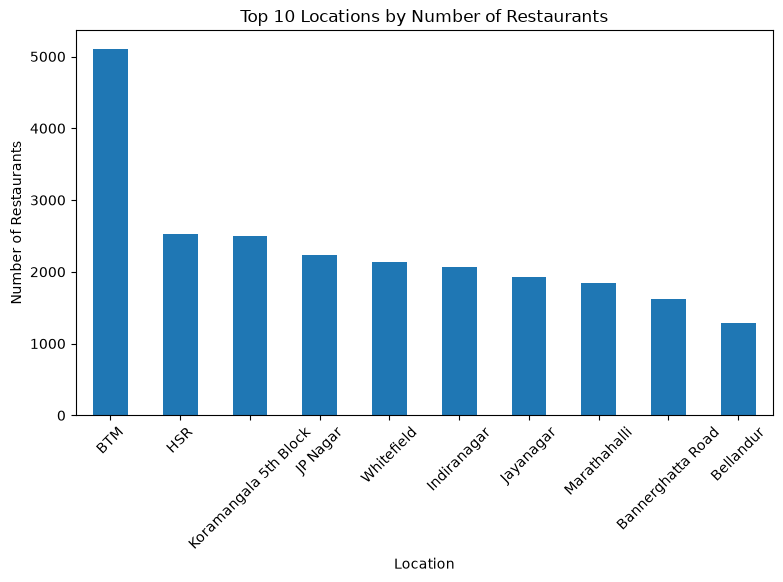

In [460]:
top_locations.plot(kind="bar", figsize=(9, 5))

plt.title("Top 10 Locations by Number of Restaurants")
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.savefig("../output/top_10_locations.png", bbox_inches="tight")
plt.show()

### 6.2 Top 10 Restaurant Types

In [452]:
top_rest_type = df["rest_type"].value_counts().head(10)

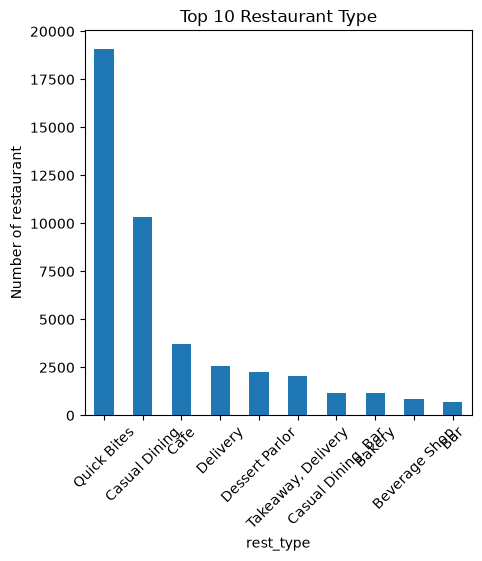

In [461]:
top_rest_type.plot(kind="bar", figsize=(5,5))
plt.title("Top 10 Restaurant Type")
plt.ylabel("Number of restaurant")
plt.xlabel("rest_type")
plt.xticks(rotation=45)
plt.savefig("../output/top_10_restaurant_types.png", bbox_inches="tight")
plt.show()

### 6.3 Online Ordering Availability

In [454]:
online_order_pct = df["online_order"].value_counts(normalize=True)*100

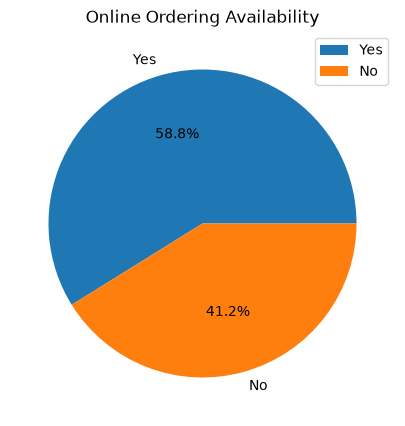

In [462]:
online_order_pct.plot(kind= "pie",figsize=(6,5), autopct="%1.1f%%", legend=True)
plt.title("Online Ordering Availability")
plt.savefig("../output/online_ordering_availability.png", bbox_inches="tight")
plt.show()

### 6.4 Average Rating vs Cost Category

In [456]:
avg_rating_cost = df.groupby("cost_category")["rate"].mean()

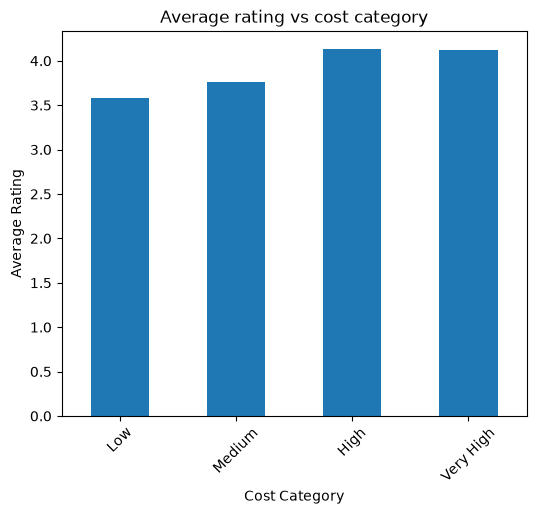

In [463]:
avg_rating_cost.plot(kind="bar", figsize=(6,5))
plt.title("Average rating vs cost category")
plt.xlabel("Cost Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.savefig("../output/average_rating_vs_cost_category.png", bbox_inches="tight")
plt.show()

### 6.5 Votes vs Restaurant Rating

In [458]:
correlation = df["rate"].corr(df["votes"])

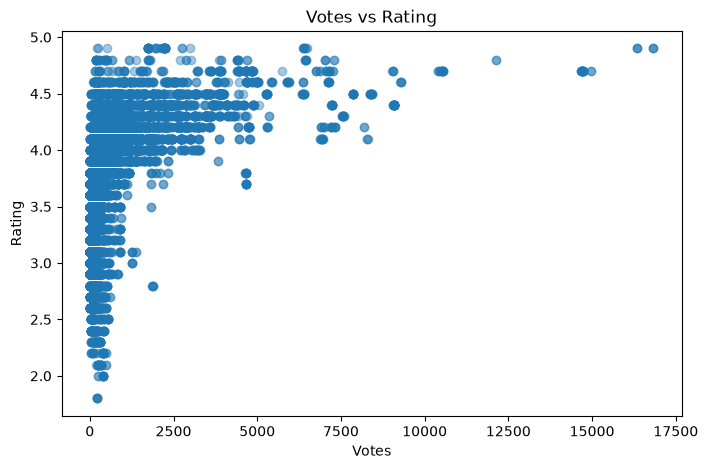

In [464]:
plt.figure(figsize=(8, 5))

plt.scatter(df["votes"], df["rate"], alpha=0.4)

plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.savefig("../output/votes_vs_rating.png", bbox_inches="tight")
plt.show()

## 7. Key Insights

### 7.1 Restaurant Distribution

- BTM has the highest number of restaurant listings among the analyzed locations.
- Quick Bites is the most common restaurant type in the dataset.

### 7.2 Online Ordering

- 58.85% of restaurants accept online orders, while 41.15% do not.
- Restaurants offering online ordering have a slightly higher average rating than restaurants without online ordering.

### 7.3 Table Booking and Ratings

- Restaurants offering table booking have a higher average rating (4.14) compared with restaurants that do not offer table booking (3.62).

### 7.4 Cost and Ratings

- Higher-cost restaurants generally have higher average ratings.
- High-cost restaurants have an average rating of approximately 4.13, while Very High-cost restaurants have an average rating of approximately 4.12.

### 7.5 Popular Cuisines

- North Indian is the most commonly listed cuisine, followed by Chinese and South Indian.
- Fast Food and Biryani are also among the most frequently listed cuisines.

### 7.6 Votes and Ratings

- The correlation between votes and restaurant ratings is approximately 0.4335, indicating a moderate positive relationship.
- This suggests that restaurants with more votes tend to have somewhat higher ratings, although correlation does not imply causation.

## 8. Conclusion

This project analyzed Bangalore restaurant data to identify patterns in
restaurant locations, restaurant types, cuisines, ratings, online ordering,
table booking, and approximate cost. The analysis showed that BTM has the
highest number of restaurant listings, North Indian is the most commonly
listed cuisine, and restaurants offering table booking generally have higher
average ratings. Higher-cost restaurants also tend to have higher ratings,
while votes and ratings show a moderate positive correlation. Overall, the
analysis demonstrates how Python and Pandas can be used to clean, explore,
and derive meaningful insights from real-world restaurant data.